In [2]:
# Allow imports from agente2 and from inside agente2 (agent_types, prompts, etc.)
import sys
from pathlib import Path

# Project root = folder containing this notebook (robot/)
_root = Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
# So that agente2/*.py can do "from agent_types import ..." etc.
sys.path.insert(0, str(_root / "mcp_benchmark"))

from mcp_benchmark.perception import interpret_scene
from mcp_benchmark import (
    PromptLLM, build_tool_registry, MCPClient)

In [3]:
llm = PromptLLM(model="gpt-4o")
mcp = MCPClient("http://localhost:8000/mcp")
await mcp.connect()

tools = await mcp.load_tools()
tool_registry = build_tool_registry(tools)

In [4]:
scene, inferred_objects, perception_interaction = await interpret_scene(
            llm,
            tool_registry["get_visible_objects"],
            tool_registry["get_visible_objects"],
            use_image=False
        )

In [5]:
from mcp_benchmark.world_state import build_world_state

world_state = await build_world_state(
            inferred_objects,
            scene,
            tool_registry["get_agent_status"],
            "sd",
            "true"
        )

In [6]:
from mcp_benchmark.prompts import ACTION_SELECTOR_PROMPT
prompt = ACTION_SELECTOR_PROMPT.format(
    goal="goal",
    initial_reasoning_section="oi",
    world_state=world_state
)

In [7]:
print(prompt)


You control an agent in a 3D environment.

Goal:
goal
oi

Current state (inferred):
Visible objects:
  - Object: Mug | ID: Mug|-00.38|+01.09|+03.19 | Distance: 2.37 | Properties: pickupable, receptacle | Screen region: top-right
  - Object: Apple | ID: Apple|-00.79|+01.11|+01.92 | Distance: 1.05 | Properties: pickupable | Screen region: center-right
  - Object: SaltShaker | ID: SaltShaker|-00.79|+01.04|+03.04 | Distance: 2.10 | Properties: pickupable | Screen region: top-right
  - Object: Plate | ID: Plate|-00.66|+01.05|+03.27 | Distance: 2.35 | Properties: pickupable, receptacle | Screen region: top-right
  - Object: DiningTable | ID: DiningTable|-00.62|+00.02|+02.49 | Distance: 1.84 | Properties: receptacle | Screen region: center-right
  - Object: CoffeeMachine | ID: CoffeeMachine|-00.15|+01.04|+03.19 | Distance: 2.46 | Properties: receptacle, toggleable | Screen region: top-right
  - Object: SoapBottle | ID: SoapBottle|-00.91|+01.05|+03.04 | Distance: 2.08 | Properties: pickupable

In [13]:
world_state

InferredWorldState(objects=[InferredObject(label='Spoon', raw_data={'distance': 1.38946664, 'objectId': 'Spoon|-02.01|+01.13|+00.66', 'objectType': 'Spoon', 'openable': False, 'pickupable': True, 'position': {'x': -2.01135373, 'y': 1.12602937, 'z': 0.6620079}, 'receptacle': False, 'screen_region': 'center-right', 'toggleable': False, 'visible': True}, relative_position=None, distance=None), InferredObject(label='Apple', raw_data={'distance': 2.56271958, 'objectId': 'Apple|-00.79|+01.11|+01.92', 'objectType': 'Apple', 'openable': False, 'pickupable': True, 'position': {'x': -0.785364747, 'y': 1.108947, 'z': 1.9207176}, 'receptacle': False, 'screen_region': 'top-left', 'toggleable': False, 'visible': True}, relative_position=None, distance=None), InferredObject(label='Bread', raw_data={'distance': 1.23539019, 'objectId': 'Bread|-02.26|+01.21|+00.57', 'objectType': 'Bread', 'openable': False, 'pickupable': True, 'position': {'x': -2.26270247, 'y': 1.19402, 'z': 0.5676719}, 'receptacle': F

In [10]:
goal = await tool_registry["get_task_instruction"]()

In [12]:
goal[0]

'{"task_instruction":"Rinse off a ladle and move it to the table.","current_step":2,"max_steps":30}'

In [13]:
from agente2.prompts import TASK_REASONING_PROMPT
reasoning_prompt = TASK_REASONING_PROMPT.format(goal="Rinse off a ladle and move it to the table.")
initial_reasoning = await llm.ainvoke(reasoning_prompt)

In [15]:
print(initial_reasoning)

**Reasoning and Plan:**

1. **Main Objective:**
   - The main objective is to rinse off a ladle and then move it to a table. This involves two primary actions: rinsing and relocating the ladle.

2. **Reasonable Strategy:**
   - **Locate the Ladle:** First, identify where the ladle is located in the environment.
   - **Approach the Ladle:** Move towards the ladle to interact with it.
   - **Pick Up the Ladle:** Once close enough, pick up the ladle.
   - **Find a Water Source:** Identify a sink or any water source where the ladle can be rinsed.
   - **Rinse the Ladle:** Use the water source to rinse off the ladle thoroughly.
   - **Locate the Table:** Identify where the table is located in the environment.
   - **Move to the Table:** Carry the ladle to the table.
   - **Place the Ladle on the Table:** Gently put the ladle down on the table.

3. **Potential Challenges:**
   - **Obstacles:** Be aware of any obstacles that might block the path to the ladle, water source, or table.
   - **Ob

In [9]:
world_state

InferredWorldState(objects=[InferredObject(label='Spoon', raw_data={'distance': 1.17208982, 'objectId': 'Spoon|-02.01|+01.13|+00.66', 'objectType': 'Spoon', 'openable': False, 'pickupable': True, 'position': {'x': -2.01135373, 'y': 1.12602937, 'z': 0.6620079}, 'receptacle': False, 'toggleable': False, 'visible': True}, relative_position=None, distance=None), InferredObject(label='Apple', raw_data={'distance': 2.32329822, 'objectId': 'Apple|-00.79|+01.11|+01.92', 'objectType': 'Apple', 'openable': False, 'pickupable': True, 'position': {'x': -0.785364747, 'y': 1.108947, 'z': 1.9207176}, 'receptacle': False, 'toggleable': False, 'visible': True}, relative_position=None, distance=None), InferredObject(label='Fork', raw_data={'distance': 1.97892737, 'objectId': 'Fork|-01.20|+00.93|+00.43', 'objectType': 'Fork', 'openable': False, 'pickupable': True, 'position': {'x': -1.1996057, 'y': 0.922727168, 'z': 0.4288656}, 'receptacle': False, 'toggleable': False, 'visible': True}, relative_position

In [7]:
scene

SceneInterpretation(visual_objects=[], front_blocked=False, camera_orientation='level', notes=None)

In [5]:
scene

SceneInterpretation(visual_objects=[], front_blocked=False, camera_orientation='level', notes=None)

In [2]:
mcp = MCPClient("http://localhost:8000/mcp")

await mcp.connect()
tools = await mcp.load_tools()

In [3]:
# Lista de nomes que você deseja remover
tools_to_remove = {'get_observation'}

# Nova lista apenas com as ferramentas cujo nome NÃO está no set acima
tools = [t for t in tools if t.name not in tools_to_remove]

In [34]:
tools

[StructuredTool(name='move_ahead', description='Avança uma unidade na direção atual.\nUse após inspecionar a cena com `get_observation()` para evitar colisões.\nCheque `lastActionSuccess`/`errorMessage` na resposta antes de seguir.', args_schema=<class '__main__.move_aheadSchema'>, coroutine=<function MCPClient._make_tool_wrapper.<locals>.tool_wrapper at 0x000001B1E1C90F60>),
 StructuredTool(name='move_back', description='Recuo de uma unidade mantendo a orientação atual.\nÚtil para desfazer um passo errado ou reposicionar para pegar objetos.\nResposta contém `lastActionSuccess`/`errorMessage`.', args_schema=<class '__main__.move_backSchema'>, coroutine=<function MCPClient._make_tool_wrapper.<locals>.tool_wrapper at 0x000001B1E1C93480>),
 StructuredTool(name='rotate_left', description='Rotaciona 90° para a esquerda (sem mover a posição).\nCombine com `get_visible_objects()` para explorar novos campos de visão.\nUse quando `visible=False` para muitos objetos à frente.', args_schema=<clas

In [4]:
import json
import base64
from PIL import Image
import io

async def test_vision_tool():
    get_image_tool = next(t for t in tools if t.name == "get_image")
    
    print("📸 Solicitando imagem ao simulador...")
    result = await get_image_tool.ainvoke({})
    
    try:
        # 1. O resultado é uma lista, pegamos o primeiro item
        raw_content = result[0] if isinstance(result, list) else result
        
        # 2. O conteúdo é uma string JSON, vamos converter em dicionário
        data = json.loads(raw_content)
        
        # 3. Agora pegamos a chave correta
        img_data = data["image_base64"]
        
        # 4. Decodifica e abre
        img_bytes = base64.b64decode(img_data)
        img = Image.open(io.BytesIO(img_bytes))
        
        img.save("test_vision.png")
        print(f"✅ Sucesso! Resolução: {img.size}")
        img.show()
        
    except Exception as e:
        print(f"❌ Erro ao processar: {e}")
        print(f"Conteúdo que causou erro: {str(result)[:100]}...")

# await test_vision_tool()


await test_vision_tool()

📸 Solicitando imagem ao simulador...
✅ Sucesso! Resolução: (800, 600)


In [5]:
from typing import Annotated, Literal, TypedDict, List, Any
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI  # ou outro LLM
from langchain_core.runnables import RunnableConfig
import asyncio

# --- Estado do grafo ---
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    next_action: str  # pode ser usado para decisões explícitas, opcional

# --- LLM (substitua com sua chave/API) ---
llm = ChatOpenAI(model="gpt-4o", temperature=0)

from langchain_core.prompts import ChatPromptTemplate


system_prompt = """
Você é um agente robótico inteligente em um ambiente 3D simulado. Sua missão é localizar e manipular objetos com persistência e estratégia.

### 🧠 REGRAS DE OURO DE PERCEPÇÃO
1. **O "Ponto Cego" do Balcão**: Objetos pequenos (como Tomates) em balcões ou mesas muitas vezes não aparecem se você estiver olhando para frente. Você DEVE usar `look_down` para escanear superfícies próximas.
2. **A Falácia do Vazio**: Se `get_visible_objects` retornar vazio, não significa que a sala está vazia. Significa que você está olhando para uma parede ou espaço vazio. MUDE sua posição com `move_ahead`.
3. **Navegação Pró-Ativa**: Se o objeto alvo não for encontrado após um giro de 360°, você não pode desistir. Você deve se mover para uma nova área da sala e repetir o processo.

### 🗺️ ESTRATÉGIA DE BUSCA (PROTOCOLO OBRIGATÓRIO)
Para encontrar um objeto (ex: Tomato):
1. **Escanear Alturas**: Use `look_down` para checar balcões e `look_up` para prateleiras altas.
2. **Varredura 360° + Movimento**:
   - Gire (4x `rotate_right/left` + `get_visible_objects`).
   - Se não encontrar, execute `move_ahead` (2 ou 3 vezes) para mudar o ângulo de visão.
   - **Mova-se em direção a receptáculos**: Se vir uma `Fridge`, `Cabinet` ou `Table`, mova-se até ela antes de concluir que o objeto não está lá.
3. **Interação**: Se o objeto pode estar dentro de algo (Fridge, Microwave), você DEVE abrir o container para inspecionar o conteúdo.

### Movimentação
- Robô só move-se para frente e para trás, para andar para os lados use o `rotate_left` e `rotate_right` e ande para frente com o `move_ahead`
- Se a posição não for válida, olhe para o lado para ter um melhor posicionamento.

### ⚠️ EXECUÇÃO DE TAREFA
- Para pegar um objeto: Ele deve estar visível e em uma distância próxima (geralmente < 1.5m). Se estiver longe, use `move_ahead`.
- Se uma ação falhar (`success=False`), tente uma manobra de ajuste: dê um passo para trás ou para o lado e tente novamente.

### 📝 PENSAMENTO LÓGICO
Antes de cada ação, descreva brevemente seu raciocínio.
Exemplo: "Raciocínio: Já girei 360 graus e não vi o tomate. Vou andar para frente para explorar o outro lado da cozinha e olhar para baixo nos balcões."
"""

system_prompt = """
Você é um agente robótico com visão avançada em um ambiente 3D. 
Sua única forma de entender o mundo ao seu redor é através da ferramenta `get_image`.

### 👁️ PROTOCOLO VISUAL OBRIGATÓRIO
1. **Ver para Crer**: Antes de qualquer interação física, você DEVE usar `get_image`.
2. **Ciclo de Ação**: Toda vez que você se mover (`move_ahead`, `rotate`) ou inclinar a câmera (`look_down`), você DEVE chamar `get_image` depois do ciclo de ações de movimento.
3. **Análise de Imagem**: Ao receber a imagem, identifique objetos, distâncias aproximadas e obstruções. Ignore metadados antigos; confie no que seus olhos veem na foto.

### 🗺️ ESTRATÉGIA DE BUSCA E NAVEGAÇÃO
- **O Tomato sumiu?**: Se você não vê o alvo na imagem:
  1. Use `look_down`. Muitos itens pequenos ficam escondidos abaixo da linha do horizonte da câmera em balcões.
  2. Gire 90° e tire uma nova foto. Repita até completar 360°.
  3. Se ainda não vir, caminhe para frente (`move_ahead`) para mudar o ângulo de perspectiva e repita a busca.
- **Aproximação**: Se vir o objeto ao longe, use `move_ahead` sucessivas vezes até que ele pareça grande o suficiente na imagem para ser coletado.

### 📦 MANIPULAÇÃO DE OBJETOS
- **Inventário**: Use `get_agent_status` para confirmar se suas mãos estão vazias antes de `pickup_object` ou para confirmar o ID do objeto que você está segurando.
- **manipulação de objetos**: use `get_visible_objects` para obter os ids e as propriedades dos objetos.
- **IDs de Objetos**: Use o contexto visual para deduzir onde os objetos estão. (Nota: Para as ferramentas de interação, utilize os IDs conhecidos ou IDs identificados visualmente em iterações anteriores).
- **Containers**: Para interagir com Frigoríficos ou Armários, aproxime-se, use `open_object`, e então `get_image` para ver o conteúdo interno.

### 📝 PENSAMENTO LÓGICO
Sempre descreva o que você está vendo na imagem antes de decidir o próximo passo.
Exemplo: "Raciocínio: Na imagem atual vejo um balcão branco à esquerda, mas não vejo o tomate. Vou girar para a direita e tirar outra foto."
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("placeholder", "{messages}")
])

tool_binded_llm = prompt | llm.bind_tools(tools)

# --- Nós do grafo ---

async def agent_node(state: AgentState, config: RunnableConfig):
    """Decide qual ação tomar a seguir."""
    response = await tool_binded_llm.ainvoke(state, config)
    return {"messages": [response]}

async def tool_node(state: AgentState):
    print("🔧 Entrou no tool_node")
    messages = state["messages"]
    last_message = messages[-1]
    
    if not last_message.tool_calls:
        return {"messages": []}

    outputs = []
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        found_tool = next((t for t in tools if t.name == tool_name), None)
        if not found_tool:
            outputs.append(ToolMessage(content=f"Tool '{tool_name}' não existe.", tool_call_id=tool_id))
            continue

        try:
            result = await found_tool.ainvoke(tool_args)

            if tool_name == "get_image":
                raw_result = result[0] if isinstance(result, list) else result
                image_info = json.loads(raw_result)
                base64_str = image_info["image_base64"]
                
                # 1. A ToolMessage precisa ser apenas TEXTO (exigência da API)
                outputs.append(ToolMessage(
                    content="Imagem capturada com sucesso. Analise a imagem enviada a seguir.", 
                    tool_call_id=tool_id
                ))
                
                # 2. Injetamos a imagem como uma HumanMessage (único lugar onde URLs de imagem são permitidas)
                image_message = HumanMessage(content=[
                    {"type": "text", "text": "Aqui está a visão atual da minha câmera:"},
                    {
                        "type": "image_url",
                        "image_url": {"url": f"data:image/png;base64,{base64_str}"}
                    }
                ])
                outputs.append(image_message)
            
            else:
                output_text = "\n".join(result) if isinstance(result, list) else str(result)
                outputs.append(ToolMessage(content=output_text, tool_call_id=tool_id))

        except Exception as e:
            outputs.append(ToolMessage(content=str(e), tool_call_id=tool_id))

    return {"messages": outputs}

def should_continue(state: AgentState) -> Literal["tool_node", "__end__"]:
    """Decide se deve continuar com tool ou terminar."""
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return "__end__"

# --- Montar o grafo ---
graph = StateGraph(AgentState)

graph.add_node("agent", agent_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "agent")
graph.add_conditional_edges("agent", should_continue)
graph.add_edge("tool_node", "agent")

app = graph.compile()

In [6]:
async def run_agent(query: str):
    config = {"recursion_limit": 200}
    inputs = {"messages": [HumanMessage(content=query)]}
    async for event in app.astream(inputs, config=config):
        for k, v in event.items():
            print(f"Node '{k}' retornou:")
            for msg in v.get("messages", []):
                print(f"  {msg}")
        print("-" * 60)

Node 'agent' retornou:
  content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 1814, 'total_tokens': 1824, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_deacdd5f6f', 'id': 'chatcmpl-Cv60wed9vii8kZ9wG1t67ZWdpxHkH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019b948d-5703-7273-a67a-58a66a222185-0' tool_calls=[{'name': 'rotate_right', 'args': {}, 'id': 'call_njmR7i2qVw5M8yTKpB3L5bP1', 'type': 'tool_call'}] usage_metadata={'input_tokens': 1814, 'output_tokens': 10, 'total_tokens': 1824, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}
----------------------------------------
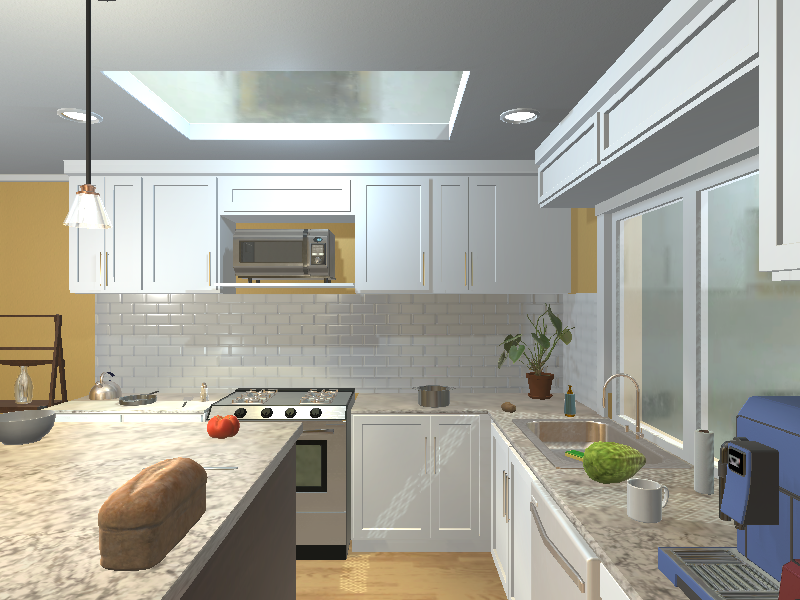

In [8]:
await run_agent("olhe para a direita")

In [3]:
from langgraph.graph import StateGraph, MessagesState, END
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)
tool_node = ToolNode(tools)


def llm_node(state: MessagesState):
    msg = llm.invoke(state["messages"])
    return {"messages": [msg]}


def should_continue(state: MessagesState):
    last_msg = state["messages"][-1]
    return "tools" if last_msg.tool_calls else END


graph = StateGraph(MessagesState)

graph.add_node("llm", llm_node)
graph.add_node("tools", tool_node)

graph.add_conditional_edges(
    "llm",
    should_continue,
    {
        "tools": "tools",
        END: END,
    },
)

graph.add_edge("tools", "llm")
graph.set_entry_point("llm")

app = graph.compile()


In [4]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

chat_state = {
    "messages": []
}

print("Chat iniciado. Digite 'sair' para encerrar.\n")

while True:
    user_input = input("Você: ")

    if user_input.lower() in {"sair", "exit", "quit"}:
        print("Encerrando chat.")
        break

    chat_state["messages"].append(HumanMessage(content=user_input))

    result = await app.ainvoke(chat_state)

    # Atualiza state completo
    chat_state["messages"] = result["messages"]

    print()

    for msg in chat_state["messages"]:
        if isinstance(msg, AIMessage) and msg.tool_calls:
            for tool_call in msg.tool_calls:
                print(f"[TOOL CALL] nome={tool_call['name']} id={tool_call['id']} args={tool_call['args']}")

        if isinstance(msg, ToolMessage):
            print(f"[TOOL RESULT] id={msg.tool_call_id} resultado={msg.content}")

    last_msg = chat_state["messages"][-1]

    if isinstance(last_msg, AIMessage) and not last_msg.tool_calls:
        print("Assistente:", last_msg.content, "\n")
    else:
        print()  # tool call finaliza turno sem resposta direta


Chat iniciado. Digite 'sair' para encerrar.


[TOOL CALL] nome=rotate_left id=call_E5ah38X07mOC2NRSpF2ucxlf args={}
[TOOL RESULT] id=call_E5ah38X07mOC2NRSpF2ucxlf resultado=["{\"error\":\"\",\"rotation\":{\"x\":0.0,\"y\":180.0,\"z\":0.0},\"success\":true}"]
Assistente: Eu olhei para a esquerda. Se precisar de mais alguma coisa, é só avisar! 

Encerrando chat.


In [5]:
from typing import List, Optional
from langchain_core.messages import BaseMessage
from pydantic import BaseModel
from langgraph.graph import StateGraph, MessagesState, END
from langgraph.prebuilt import ToolNode
from langchain_openai import ChatOpenAI


llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools)

class AgentState(BaseModel):
    messages: List[BaseMessage]
    last_action_success: Optional[bool] = None
    inventory: Optional[list] = None
    visible_objects: Optional[list] = None

SYSTEM_PROMPT = """
Você é um agente inteligente que controla um ambiente interativo.
Sua função é raciocinar sobre o estado atual, planejar e executar ações usando ferramentas.

Regras obrigatórias:

1. Sempre verifique `lastActionSuccess` antes de executar qualquer nova ação.
2. Sempre chame `get_visible_objects()` para entender o que está ao redor antes de interagir.
3. Verifique o inventário antes de tentar pegar outro objeto.
4. Verifique propriedades dos objetos (`pickupable`, `receptacle`, etc.) antes de interagir.
5. Use `Pass` para aguardar efeitos (ex: aquecimento, cooldowns).
6. Trate erros adequadamente – objetos podem não estar acessíveis.
7. Navegue primeiro – objetos podem não estar visíveis na sua posição atual.

Você sempre deve escolher a tool adequada com base no objetivo atual.
Planeje em voz alta antes de agir.
"""


In [6]:
import json
from typing import List, Optional, Annotated, Literal
from langchain_core.messages import BaseMessage, SystemMessage, HumanMessage, AIMessage, ToolMessage
from pydantic import BaseModel
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_openai import ChatOpenAI

tools_map = {t.name: t for t in tools}

llm = ChatOpenAI(model="gpt-4o-mini").bind_tools(tools, tool_choice="auto")

# 2. Definição do Estado (Corrigida)
class AgentState(BaseModel):
    # 'add_messages' é essencial para manter o histórico da conversa
    messages: Annotated[List[BaseMessage], add_messages]
    last_action_success: Optional[bool] = True
    inventory: Optional[list] = None
    visible_objects: Optional[list] = None

# 3. Nó do Agente (LLM)
def llm_node(state: AgentState):
    # Injeta o System Prompt + Estado atualizado
    status_msg = f"""
    [Estado Atual]
    - lastActionSuccess: {state.last_action_success}
    - inventário: {state.inventory}
    - objetos visíveis: {state.visible_objects}
    """
    
    # Monta a lista de mensagens mantendo o histórico
    messages = [SystemMessage(content=SYSTEM_PROMPT + status_msg)] + state.messages
    
    response = llm.invoke(messages)
    
    return {"messages": [response]}

# 4. Nó de Ferramentas (Corrigido para ler tool_calls)
async def tool_node(state: AgentState):
    last_message = state.messages[-1]
    
    # Se não houver chamadas de ferramenta, sai (segurança)
    if not isinstance(last_message, AIMessage) or not last_message.tool_calls:
        return {"last_action_success": False}

    results = []
    action_success = True
    
    # Itera sobre as chamadas que o GPT gerou
    for tool_call in last_message.tool_calls:
        tool_name = tool_call["name"]
        args = tool_call["args"]
        call_id = tool_call["id"]

        print(f"🔧 [TOOL CALL] Executando: {tool_name} com args: {args}")

        try:
            # Busca a ferramenta na sua lista 'tools' existente
            selected_tool = tools_map[tool_name]
            
            # Executa (verifica se é async ou sync)
            if selected_tool.coroutine:
                result = await selected_tool.arun(args)
            else:
                result = selected_tool.run(args)

            print(f"✅ [TOOL RESULT] {result}")

            # Cria a ToolMessage (obrigatório para o fluxo voltar ao LLM)
            results.append(ToolMessage(
                content=str(result),
                tool_call_id=call_id,
                name=tool_name
            ))
            
            # Lógica simples de atualização de sucesso baseada em dicionário de retorno
            if isinstance(result, dict) and result.get("success") is False:
                action_success = False

        except Exception as e:
            print(f"[TOOL ERROR] {tool_name}: {e}")
            results.append(ToolMessage(
                content=f"Error: {str(e)}", 
                tool_call_id=call_id, 
                name=tool_name,
                status="error"
            ))
            action_success = False

    return {
        "messages": results,
        "last_action_success": action_success
    }

# 5. Lógica Condicional (Decide se para ou continua)
def should_continue(state: AgentState) -> Literal["tools", END]:
    last_message = state.messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

# 6. Montagem do Grafo
workflow = StateGraph(AgentState)

workflow.add_node("agent", llm_node)
workflow.add_node("tools", tool_node)

workflow.set_entry_point("agent")

workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "tools": "tools",
        END: END
    }
)

workflow.add_edge("tools", "agent")

app = workflow.compile()

print("Grafo compilado com sucesso.")

Grafo compilado com sucesso.


In [ ]:
# Loop interativo para Jupyter Notebook
print("🤖 Agente iniciado. (Digite 'sair' para encerrar)\n")

# Variáveis de estado persistentes (simulação)
current_inventory = []
current_visible = []
last_success = True

# Histórico inicial vazio (gerenciado pelo LangGraph, mas inicializado aqui)
chat_history = [] 

while True:
    try:
        user_input = input("Você: ")
        if user_input.lower() in {"sair", "exit"}:
            print("Encerrando...")
            break

        # Prepara o input para o grafo
        inputs = {
            "messages": [HumanMessage(content=user_input)],
            "last_action_success": last_success,
            # Se suas tools retornam inventário real, você atualizaria aqui
            "inventory": current_inventory, 
            "visible_objects": current_visible
        }

        print("--- Raciocinando ---")
        
        # 'astream' permite ver passo a passo. 'values' retorna o estado completo.
        async for event in app.astream(inputs, stream_mode="values"):
            message = event["messages"][-1]
            
            # Mostra apenas a resposta final do agente (texto), ignorando tool calls intermediários
            if isinstance(message, AIMessage) and not message.tool_calls:
                print(f"Agente: {message.content}")
                
            # Opcional: Atualizar variáveis locais baseadas no estado final
            # last_success = event.get("last_action_success", True)
                
    except Exception as e:
        import traceback
        traceback.print_exc()
        break

🤖 Agente iniciado. (Digite 'sair' para encerrar)

--- Raciocinando ---
🔧 [TOOL CALL] Executando: get_visible_objects com args: {}
✅ [TOOL RESULT] ['[{"distance":0.985802948,"objectId":"CounterTop|-00.08|+01.15|00.00","objectType":"CounterTop","properties":{"openable":false,"pickupable":false,"receptacle":true,"sliceable":false,"toggleable":false},"state":{"isDirty":false,"isOpen":false,"isToggled":false}},{"distance":2.318094,"objectId":"Cabinet|-01.55|+00.50|-01.97","objectType":"Cabinet","properties":{"openable":true,"pickupable":false,"receptacle":true,"sliceable":false,"toggleable":false},"state":{"isDirty":false,"isOpen":false,"isToggled":false}},{"distance":1.97657716,"objectId":"Window|-02.23|+01.43|-01.20","objectType":"Window","properties":{"openable":false,"pickupable":false,"receptacle":false,"sliceable":false,"toggleable":false},"state":{"isDirty":false,"isOpen":false,"isToggled":false}},{"distance":1.96890736,"objectId":"Sink|-01.90|+00.97|-01.50","objectType":"Sink","prop